<a href="https://colab.research.google.com/github/karrielaugustin001-del/Machine-Learning-Foundations/blob/main/Assignment_8_Module9_Student_Starter_KA_04_05_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 9 Assignment  
## Unsupervised Learning and Representation  
### Colab ML Lab Notebook

**Lecture Marker:** Representation first, structure second, interpretation last.

This lab includes:
- a large dataset,
- portable `pathlib` file loading,
- PCA,
- K-Means,
- multiple clustering metrics,
- written interpretation and APA paper directions.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def get_data_path(filename="unsupervised_representation_data.csv"):
    candidates = [
        Path(filename),
        Path("/content") / filename,
        Path("/mnt/data/module9_unsupervised_assignment") / filename,
        Path.cwd() / filename,
    ]
    for p in candidates:
        if p.exists():
            print("Using dataset:", p)
            return p
    raise FileNotFoundError(filename)

## Part 1 — Load and Inspect the Dataset
Load the CSV with `pd.read_csv()`, inspect shape, head, and summary statistics. Do **not** use `region_id` for unsupervised fitting.

In [5]:
data_path = get_data_path("unsupervised_representation_data.csv")
df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()


X = df.drop(columns=["region_id"])
display(df.describe())

Using dataset: unsupervised_representation_data.csv
Shape: (3000, 14)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,noise_0,noise_1,noise_2,region_id
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,-2.804968,5.667436,-0.625871,2.764011,0.073667,-7.381873,-2.731383,-1.920291,-1.517132,6.258888,0.004701,-0.042091,0.052281,2.000000
std,4.017881,3.688491,7.144411,5.013899,5.123401,2.076330,5.164856,5.350641,2.358157,6.176441,1.539170,1.966872,1.716610,1.414449
min,-13.822442,-3.995431,-15.496808,-8.726401,-10.176633,-16.728850,-12.727849,-13.513719,-8.843192,-7.877911,-5.754983,-7.844801,-2.998485,0.000000
25%,-5.163516,2.657185,-6.992396,-1.015772,-4.867076,-8.597709,-7.363715,-5.739749,-3.015318,1.417426,-1.047895,-1.344073,-1.392388,1.000000
50%,-2.564846,6.219940,-1.335059,2.491405,0.911923,-7.313665,-3.732723,-2.979370,-1.418558,4.879298,-0.023713,-0.045702,0.117296,2.000000
75%,-0.131038,8.756035,5.302521,6.756883,3.909241,-6.123448,2.138779,-0.144413,0.088591,11.750076,1.054842,1.266497,1.506379,3.000000
max,8.777066,13.637564,14.587217,16.456307,12.845452,0.472603,10.169758,12.035008,5.256709,24.002121,5.293583,6.755536,2.999549,4.000000


## Check for Missing Data

In [13]:
print('Missing values per column:')
display(df.isnull().sum())
print(f'\nTotal missing values in the dataset: {df.isnull().sum().sum()}')

Missing values per column:


,0
feature_0,0
feature_1,0
feature_2,0
feature_3,0
feature_4,0
feature_5,0
feature_6,0
feature_7,0
feature_8,0
feature_9,0



Total missing values in the dataset: 0


## Check for Duplicated Data

In [14]:
print(f'Number of duplicated rows: {df.duplicated().sum()}')
if df.duplicated().sum() > 0:
    print('\nDuplicated rows (first 5):')
    display(df[df.duplicated()].head())

Number of duplicated rows: 0


## Part 1.1 — Additional Statistical Analysis of the Dataset

Let's look at the correlation matrix and feature distributions.

In [18]:
print('Correlation Matrix of Features:')
display(X.corr())

Correlation Matrix of Features:


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,noise_0,noise_1,noise_2
feature_0,1.000000,-0.281525,-0.775536,0.141471,0.519155,0.202552,-0.452019,-0.276465,0.942313,0.730379,-0.029413,-0.006808,0.005761
feature_1,-0.281525,1.000000,0.521613,0.360837,-0.621467,-0.124542,0.148211,0.436677,-0.269657,-0.009752,0.002350,-0.011184,0.014925
feature_2,-0.775536,0.521613,1.000000,-0.067826,-0.801541,-0.130543,0.221634,0.615429,-0.733709,-0.848967,0.013064,0.013001,-0.007107
feature_3,0.141471,0.360837,-0.067826,1.000000,0.128865,0.202663,0.003006,-0.135491,0.133496,0.294830,0.009129,-0.025231,0.000171
feature_4,0.519155,-0.621467,-0.801541,0.128865,1.000000,0.130089,-0.012572,-0.766896,0.489628,0.560677,-0.004398,0.000203,0.007710
feature_5,0.202552,-0.124542,-0.130543,0.202663,0.130089,1.000000,-0.398662,0.087337,0.189328,0.077966,-0.012092,-0.018111,0.019855
feature_6,-0.452019,0.148211,0.221634,0.003006,-0.012572,-0.398662,1.000000,-0.420617,-0.426685,-0.166406,0.032742,0.007301,-0.012269
feature_7,-0.276465,0.436677,0.615429,-0.135491,-0.766896,0.087337,-0.420617,1.000000,-0.265631,-0.455847,-0.004261,0.006493,0.010694
feature_8,0.942313,-0.269657,-0.733709,0.133496,0.489628,0.189328,-0.426685,-0.265631,1.000000,0.688514,-0.024469,-0.002633,0.004107
feature_9,0.730379,-0.009752,-0.848967,0.294830,0.560677,0.077966,-0.166406,-0.455847,0.688514,1.000000,-0.010945,-0.024675,0.017242


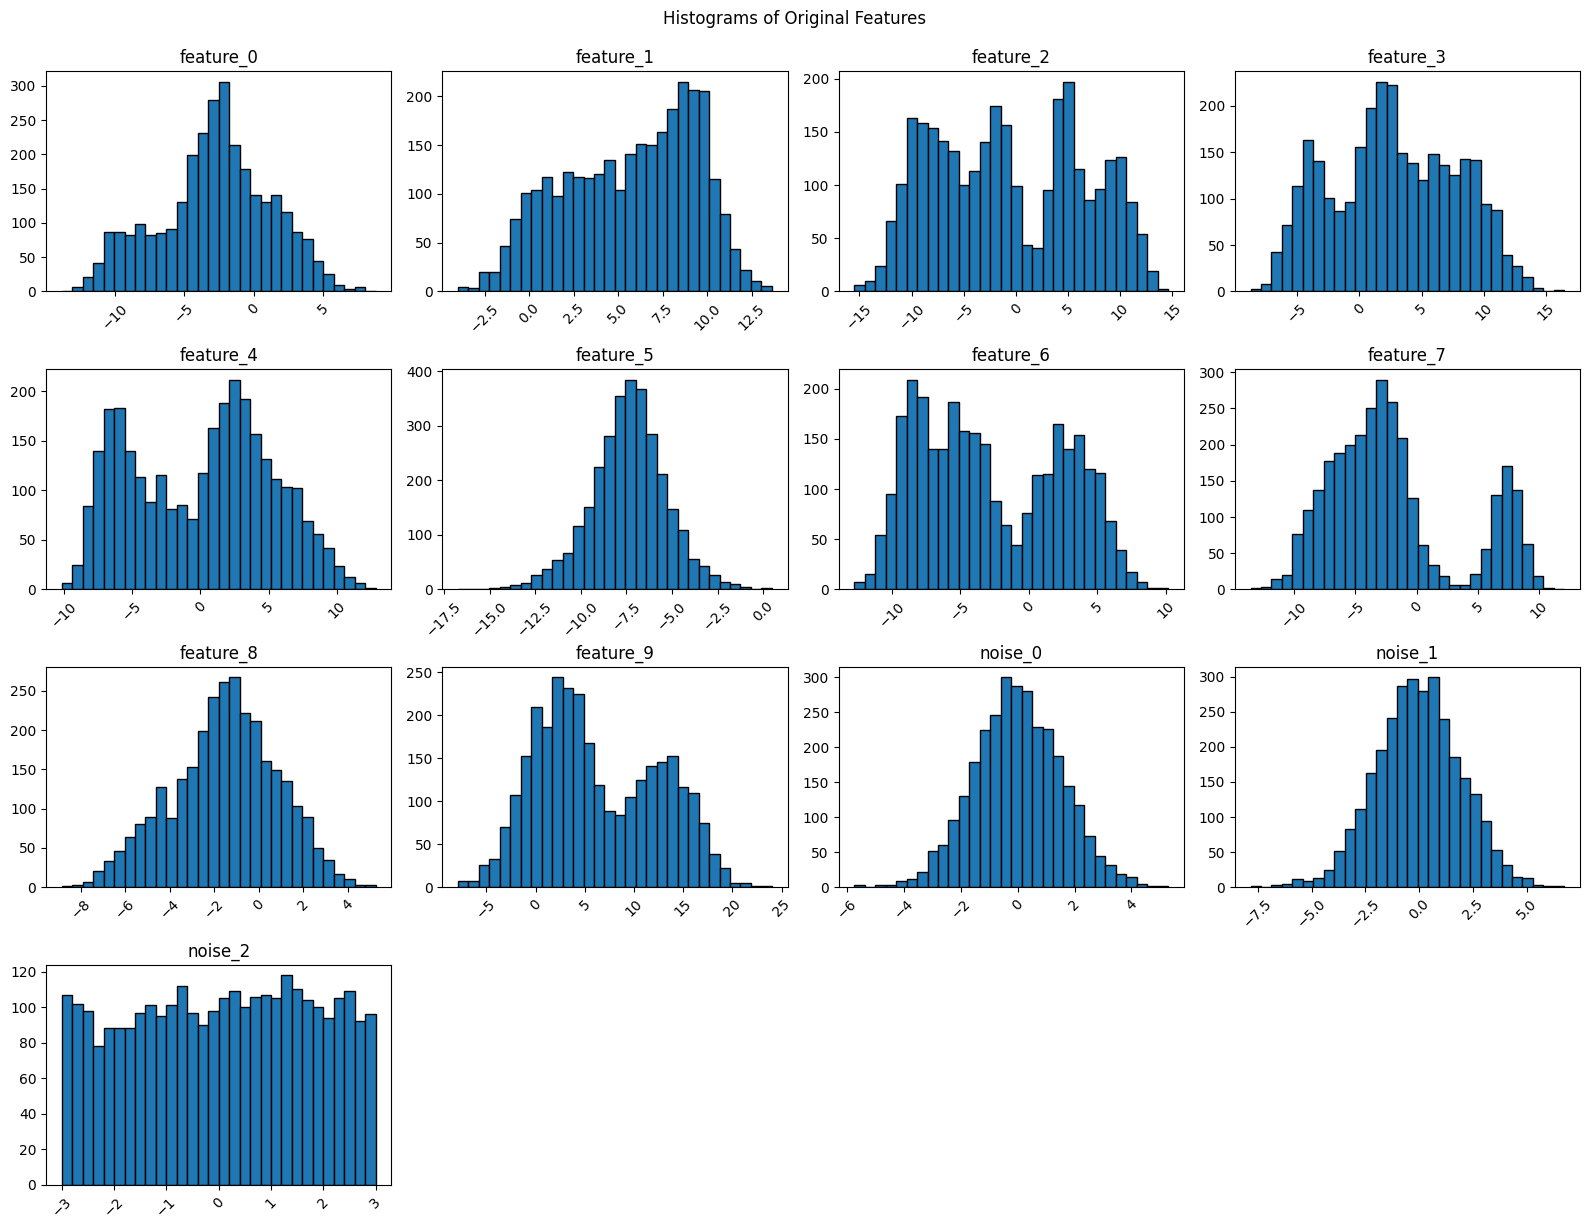

In [19]:
import matplotlib.pyplot as plt

# Plot histograms for each feature in X
num_features = X.shape[1]
num_cols = 4  # Number of columns for the subplot grid
num_rows = (num_features + num_cols - 1) // num_cols # Calculate number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 3))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=30, edgecolor='k')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Histograms of Original Features', y=1.02) # Add a super title
plt.show()

In [21]:
print("Descriptive statistics for the feature matrix X:")
display(X.describe())

Descriptive statistics for the feature matrix X:


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,noise_0,noise_1,noise_2
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,-2.804968,5.667436,-0.625871,2.764011,0.073667,-7.381873,-2.731383,-1.920291,-1.517132,6.258888,0.004701,-0.042091,0.052281
std,4.017881,3.688491,7.144411,5.013899,5.123401,2.076330,5.164856,5.350641,2.358157,6.176441,1.539170,1.966872,1.716610
min,-13.822442,-3.995431,-15.496808,-8.726401,-10.176633,-16.728850,-12.727849,-13.513719,-8.843192,-7.877911,-5.754983,-7.844801,-2.998485
25%,-5.163516,2.657185,-6.992396,-1.015772,-4.867076,-8.597709,-7.363715,-5.739749,-3.015318,1.417426,-1.047895,-1.344073,-1.392388
50%,-2.564846,6.219940,-1.335059,2.491405,0.911923,-7.313665,-3.732723,-2.979370,-1.418558,4.879298,-0.023713,-0.045702,0.117296
75%,-0.131038,8.756035,5.302521,6.756883,3.909241,-6.123448,2.138779,-0.144413,0.088591,11.750076,1.054842,1.266497,1.506379
max,8.777066,13.637564,14.587217,16.456307,12.845452,0.472603,10.169758,12.035008,5.256709,24.002121,5.293583,6.755536,2.999549


In [23]:
feature_ranges = X.max() - X.min()
print("Features sorted by range (largest to smallest):")
display(feature_ranges.sort_values(ascending=False))

Features sorted by range (largest to smallest):


,0
feature_9,31.880032
feature_2,30.084025
feature_7,25.548727
feature_3,25.182709
feature_4,23.022085
feature_6,22.897607
feature_0,22.599508
feature_1,17.632995
feature_5,17.201453
noise_1,14.600337


## Part 2 — Scale Features and Apply PCA
Standardize the features and reduce them to two principal components.

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.34893354 0.14665147]
Total variance explained: 0.4955850038913915


## Part 3 — Compare Cluster Counts
Try k from 2 to 8 and compute Silhouette, Davies-Bouldin, Calinski-Harabasz, and inertia.

In [8]:
results = []
for k in range(2, 9): # k from 2 to 8
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    kmeans.fit(X_pca)
    labels = kmeans.labels_
    inertia = kmeans.inertia_

    silhouette = silhouette_score(X_pca, labels)
    davies_bouldin = davies_bouldin_score(X_pca, labels)
    calinski_harabasz = calinski_harabasz_score(X_pca, labels)

    results.append({
        'k': k,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Score': davies_bouldin,
        'Calinski-Harabasz Score': calinski_harabasz,
        'Inertia': inertia
    })

metrics_df = pd.DataFrame(results)
print(metrics_df)

   k  Silhouette Score  Davies-Bouldin Score  Calinski-Harabasz Score  \
0  2          0.516566              0.867224              3504.592189   
1  3          0.596487              0.497506              4038.796790   
2  4          0.664634              0.458309              9558.074760   
3  5          0.594603              0.617052              9997.543243   
4  6          0.557729              0.685941              9507.113275   
5  7          0.471167              0.815924              8412.590141   
6  8          0.526624              0.794045              8142.213353   

       Inertia  
0  8911.029347  
1  5230.491867  
2  1828.409350  
3  1346.720427  
4  1145.245019  
5  1081.934882  
6   964.018134  


### Visualizing Clustering Metrics

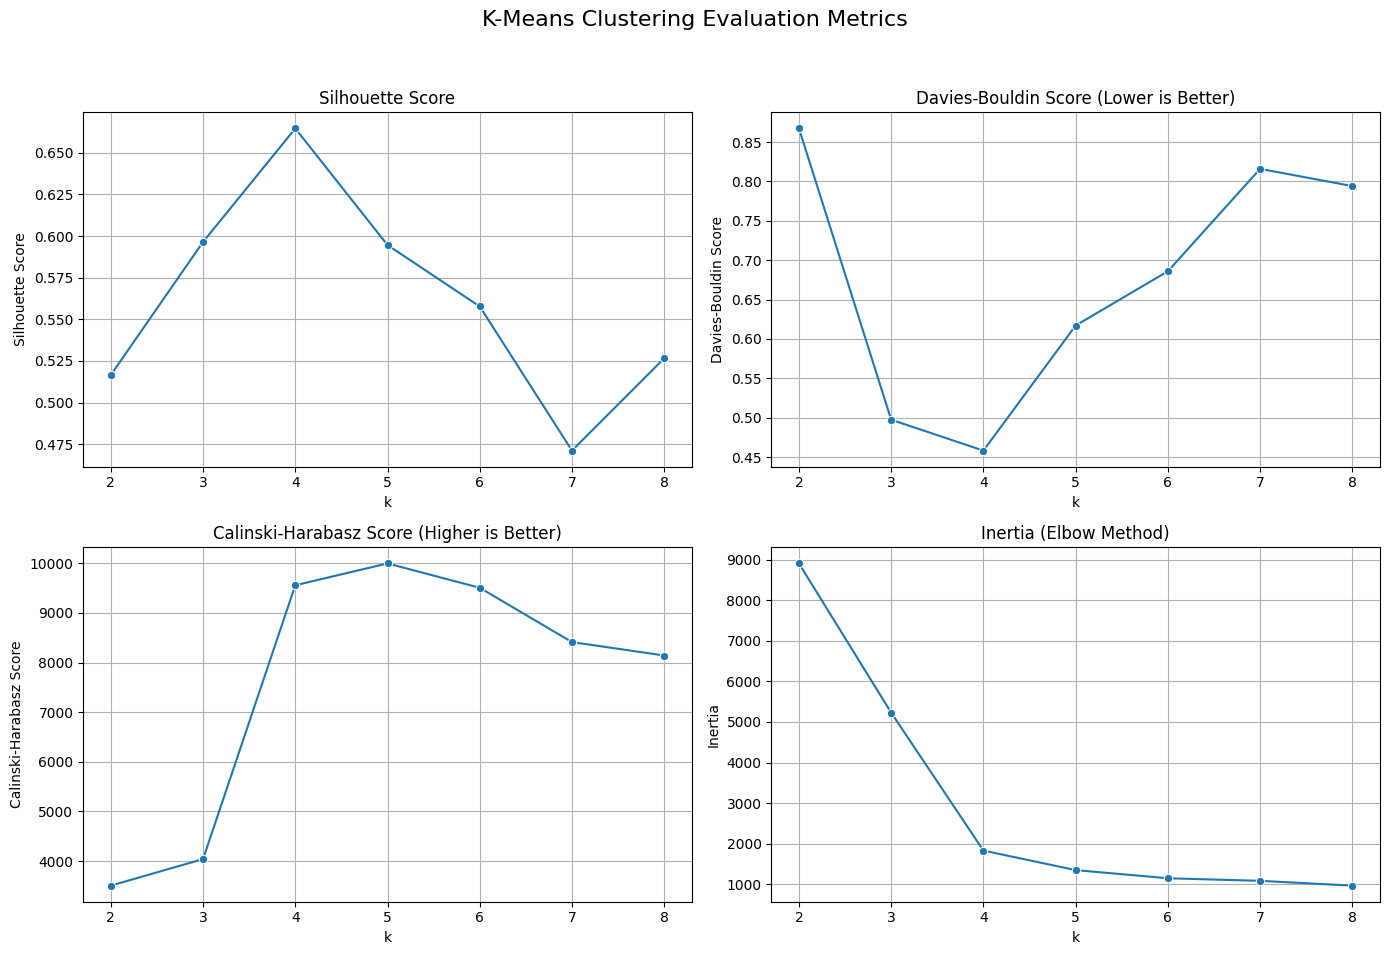

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('K-Means Clustering Evaluation Metrics', fontsize=16)

# Silhouette Score
sns.lineplot(x='k', y='Silhouette Score', data=metrics_df, marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Silhouette Score')
axes[0, 0].set_xticks(metrics_df['k'])
axes[0, 0].grid(True)

# Davies-Bouldin Score
sns.lineplot(x='k', y='Davies-Bouldin Score', data=metrics_df, marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Davies-Bouldin Score (Lower is Better)')
axes[0, 1].set_xticks(metrics_df['k'])
axes[0, 1].grid(True)

# Calinski-Harabasz Score
sns.lineplot(x='k', y='Calinski-Harabasz Score', data=metrics_df, marker='o', ax=axes[1, 0])
axes[1, 0].set_title('Calinski-Harabasz Score (Higher is Better)')
axes[1, 0].set_xticks(metrics_df['k'])
axes[1, 0].grid(True)

# Inertia (Elbow Method)
sns.lineplot(x='k', y='Inertia', data=metrics_df, marker='o', ax=axes[1, 1])
axes[1, 1].set_title('Inertia (Elbow Method)')
axes[1, 1].set_xticks(metrics_df['k'])
axes[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

## Part 4 — Plot the Representation and Final Cluster Solution
Visualize PCA space before and after cluster assignment.

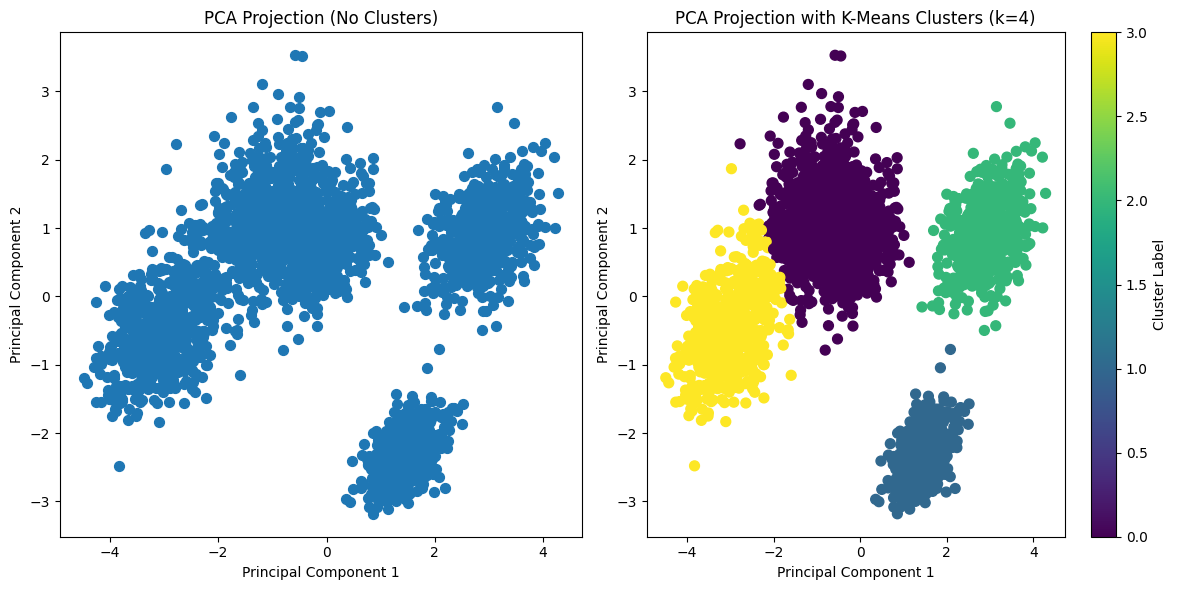

In [10]:
# Plot plain PCA projection
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=50)
plt.title('PCA Projection (No Clusters)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Choose best_k based on metrics
best_k = 4 # From analysis of metrics_df: k=4 has best Silhouette and Davies-Bouldin, and high Calinski-Harabasz

# Re-run KMeans with best_k to get final labels
kmeans_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init='auto')
kmeans_best.fit(X_pca)
final_labels = kmeans_best.labels_

# Plot K-Means cluster labels
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, s=50, cmap='viridis')
plt.title(f'PCA Projection with K-Means Clusters (k={best_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Label')
plt.tight_layout()
plt.show()

## Part 5 — Written Interpretation and Reflection

Respond in markdown:
1. What structure becomes visible after PCA?
2. Which `k` seems most reasonable, and why?
3. What do the metrics suggest about cluster quality?
4. What are the main risks of overinterpreting these clusters?
5. Why should unsupervised outputs be treated as hypotheses rather than truth?

## Submission
Write a 2–3 page APA-formatted paper with embedded code, outputs, and visuals.
Submit a Word or PDF to Canvas by **Sunday, 11:59 PM**.